<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/07_Forecasting_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7 실습: 예측, 백테스트, 성능평가
**Notebook:** `07_Forecasting_and_Evaluation.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. 표본 내 적합(In-sample fit)과 표본 외 예측(Out-of-sample forecast)의 차이를 확인합니다.
2. 시계열 데이터에서 시간 순서를 유지한 학습/테스트 분할을 수행합니다.
3. Mean, Naive, Seasonal Naive와 같은 베이스라인 예측을 구현합니다.
4. ARIMA 모형을 이용한 고정 분할(one-shot forecast) 예측을 수행합니다.
5. 확장 윈도우(Expanding window)와 롤링 윈도우(Rolling window) 기반의 walk-forward validation을 구현합니다.
6. MAE, RMSE, MAPE를 계산하여 모형 성능을 비교합니다.
7. 실제값과 예측값을 시각적으로 비교하여 백테스트 결과를 해석합니다.

---

## 왜 이 실습이 중요한가?
시계열 예측의 목적은 과거 데이터를 잘 설명하는 것이 아니라, **아직 관측되지 않은 미래 구간에서 얼마나 잘 작동하는지 검증하는 것**입니다.  
따라서 단순한 in-sample 적합만으로는 모델의 실전 성능을 판단할 수 없습니다.

특히 시계열 데이터는 시간 순서가 핵심이므로, 일반적인 무작위 K-Fold 검증을 그대로 적용하면 데이터 누수(Information Leakage)가 발생합니다.  
이번 실습에서는 이러한 문제를 피하기 위해 **chronological split**, **walk-forward validation**, **baseline comparison**을 모두 포함한 실전형 평가 절차를 구현합니다.


## 이 실습을 읽는 방법
이번 노트북은 단순히 코드를 실행하는 실습 파일이 아니라, **부교재의 논리를 코드로 옮긴 실험실**처럼 구성되어 있습니다.  
따라서 각 셀을 실행할 때는 다음 질문을 함께 던지는 것이 좋습니다.

- 지금 보는 결과는 **표본 내 설명력**인가, 아니면 **표본 외 예측력**인가?
- 이 성능은 단순 기준선보다 정말 나은가?
- 예측 구조가 현실적인 운영 상황, 즉 “새로운 데이터가 들어오면 다시 예측해야 하는 상황”을 반영하는가?

이 질문을 놓치지 않으면, 단순한 함수 사용을 넘어 **예측 실험 설계의 사고방식**을 익힐 수 있습니다.


In [1]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 온라인 환경 준비
이번 실습은 Google Colab 또는 Jupyter Notebook에서 바로 실행할 수 있도록 구성했습니다.

실제 금융 시계열 예시를 위해 `yfinance`를 사용합니다.  
설치되어 있지 않다면 자동으로 설치합니다.


In [2]:
# ============================================
# 2. yfinance 설치 및 임포트
# ============================================

try:
    import yfinance as yf
    print("yfinance가 이미 설치되어 있습니다.")
except ImportError:
    print("yfinance가 설치되어 있지 않아 지금 설치합니다...")
    !pip -q install yfinance
    import yfinance as yf
    print("yfinance 설치가 완료되었습니다.")


yfinance가 이미 설치되어 있습니다.


## 2. 시각화 기본 설정
이번 버전도 Colab 호환성을 위해 **그래프 텍스트는 영어**로 출력합니다.  
마크다운 셀과 코드 주석은 한글로 유지합니다.


In [3]:
# ============================================
# 3. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


## 3. 평가 지표와 ARIMA 도구 불러오기
이번 실습에서는 예측 성능 비교를 위해 다음 지표를 사용합니다.

- MAE
- RMSE
- MAPE

또한 예시 모형으로 ARIMA를 사용합니다.


In [4]:
# ============================================
# 4. 예측 및 평가 도구 불러오기
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA


## 4. 예시 데이터 불러오기
walk-forward validation은 계산 비용이 크기 때문에,  
이번 실습에서는 **GOOGL 일별 종가를 월말 종가(month-end close)로 재표집한 월별 시계열**을 사용합니다.

이렇게 하면
- 시계열 길이가 적절하고
- 추세를 포함하며
- 실제 백테스트 루프를 충분히 빠르게 실습할 수 있습니다.


In [5]:
# ============================================
# 5. GOOGL 데이터 다운로드
# ============================================

ticker = "GOOGL"
start_date = "2015-01-01"
end_date = "2024-12-31"

raw_df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

print(f"Ticker: {ticker}")
print(f"Raw shape: {raw_df.shape}")
display(raw_df.head())


Ticker: GOOGL
Raw shape: (2515, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,,
2015-01-02,26.260460,26.477501,26.790001,26.393999,26.629999,26480000
2015-01-05,25.760094,25.973000,26.399500,25.887501,26.357500,41182000
2015-01-06,25.124350,25.332001,26.060499,25.277500,26.025000,54456000
2015-01-07,25.050459,25.257500,25.574499,25.182501,25.547501,46918000
2015-01-08,25.137737,25.345501,25.375000,24.750999,25.075500,73054000


## 5. MultiIndex 컬럼을 고려한 종가 추출
`yfinance`는 환경에 따라 MultiIndex 컬럼 구조를 반환할 수 있습니다.  
따라서 안전하게 종가 시리즈를 꺼내는 helper 함수를 사용합니다.


In [6]:
# ============================================
# 6. 종가 시리즈를 안전하게 추출하는 함수
# ============================================

def get_close_series(df, ticker):
    if isinstance(df.columns, pd.MultiIndex):
        return df[("Close", ticker)].copy()
    return df["Close"].copy()

close_daily = get_close_series(raw_df, ticker)
close_daily.name = "Close"

display(close_daily.head())


,Close
Date,
2015-01-02,26.477501
2015-01-05,25.973000
2015-01-06,25.332001
2015-01-07,25.257500
2015-01-08,25.345501


## 6. 월별 시계열로 재표집
일별 데이터는 walk-forward ARIMA 반복 적합 시 계산량이 커집니다.  
따라서 월말 종가를 사용하여 월별 시계열로 변환합니다.

이번 실습에서는 이 월별 시계열을 예측 대상으로 사용합니다.


In [7]:
# ============================================
# 7. 월말 종가로 재표집
# ============================================

series = close_daily.resample("M").last().dropna()
series.name = "GOOGL_Monthly_Close"

print("Monthly length:", len(series))
display(series.head())


Monthly length: 120


,GOOGL_Monthly_Close
Date,
2015-01-31,26.877501
2015-02-28,28.131500
2015-03-31,27.735001
2015-04-30,27.438499
2015-05-31,27.266001


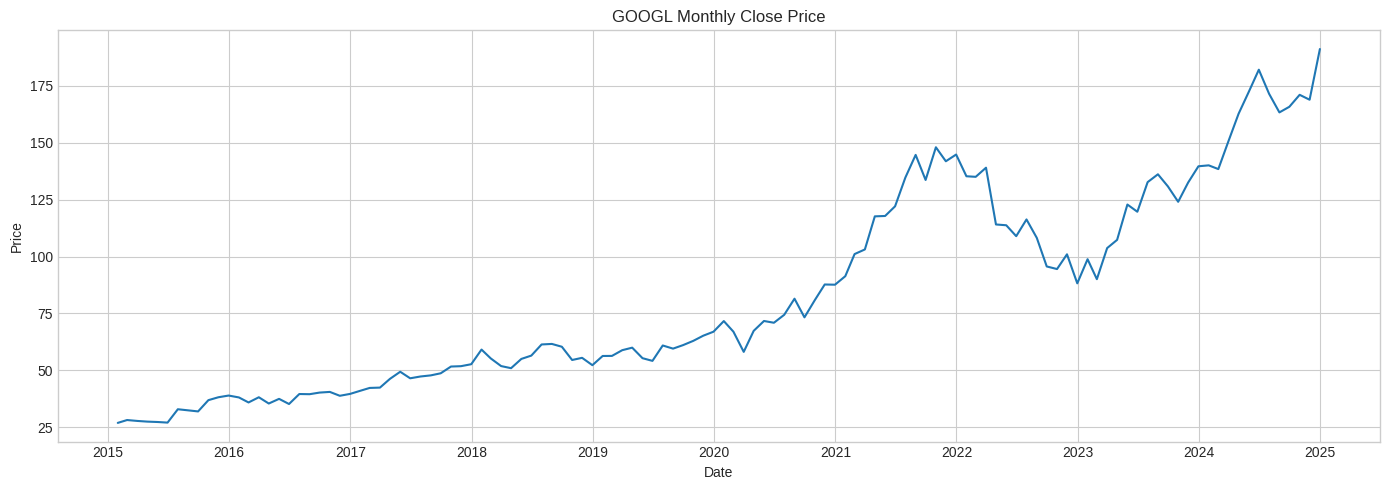

In [8]:
# ============================================
# 8. 원시 시계열 플롯
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(series.index, series, linewidth=1.5)

plt.title("GOOGL Monthly Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


## 7. 시간순 데이터 분할 (Chronological Split)
시계열 예측에서는 데이터를 무작위로 섞지 않습니다.  
가장 과거 구간을 학습용(train), 가장 최근 구간을 테스트용(test)으로 둡니다.

이번 실습에서는 마지막 24개월을 테스트 구간으로 사용합니다.


## 시간순 분할이 왜 중요한가?
일반적인 머신러닝에서는 데이터를 무작위로 섞어도 큰 문제가 없는 경우가 많습니다.  
그러나 시계열에서는 오늘의 값이 어제, 지난달, 작년과 연결되어 있기 때문에 **순서를 무작위로 섞는 순간 미래 정보가 과거로 새어 들어가는 데이터 누수**가 발생합니다.

즉, 시계열 예측의 핵심 원칙은 다음과 같습니다.

1. **과거로 학습한다.**
2. **미래를 예측한다.**
3. **미래 정보는 절대 학습에 섞지 않는다.**

이 원칙을 지키는 가장 기본적인 방식이 chronological split입니다.


In [9]:
# ============================================
# 9. Train / Test split
# ============================================

test_size = 24

train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

print("Train length:", len(train))
print("Test length :", len(test))

display(pd.DataFrame({
    "Train_End": [train.index.max()],
    "Test_Start": [test.index.min()],
    "Test_End": [test.index.max()]
}))


Train length: 96
Test length : 24


,Train_End,Test_Start,Test_End
0,2022-12-31,2023-01-31,2024-12-31


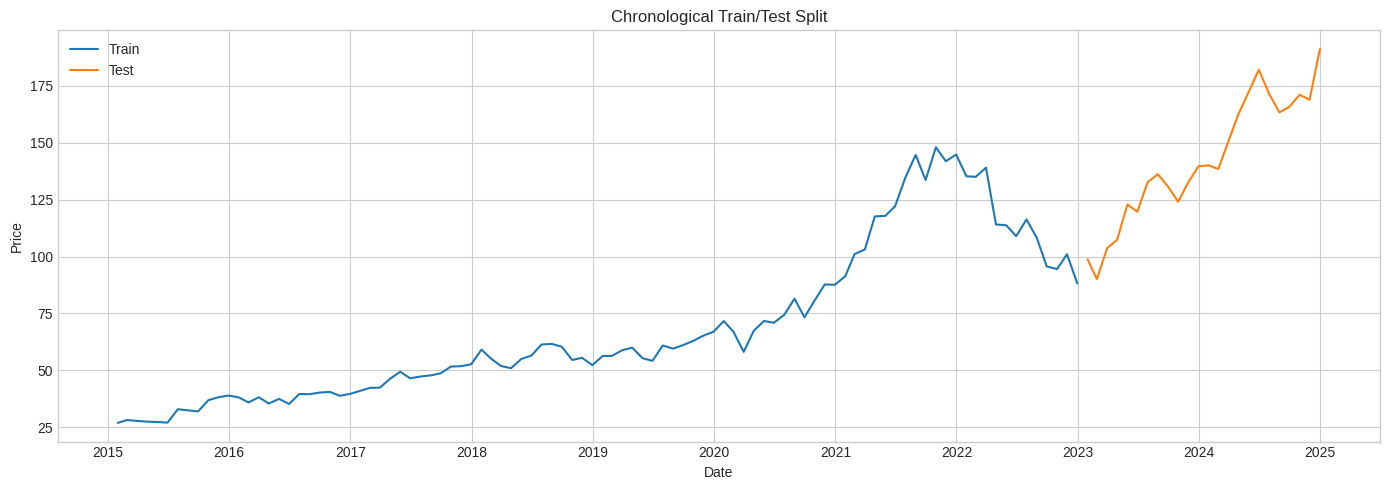

In [10]:
# ============================================
# 10. Train / Test 구간 시각화
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label="Train", linewidth=1.5)
plt.plot(test.index, test, label="Test", linewidth=1.5)

plt.title("Chronological Train/Test Split")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


## 8. 평가 지표 함수 만들기
MAPE는 실제값이 0 근처일 때 불안정할 수 있으므로,  
일반적으로 MAE와 RMSE도 함께 확인하는 것이 좋습니다.


In [11]:
# ============================================
# 11. 평가 지표 함수
# ============================================

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_forecast(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_value = mape(y_true, y_pred)
    return pd.DataFrame({
        "Model": [model_name],
        "MAE": [mae],
        "RMSE": [rmse],
        "MAPE": [mape_value]
    })


## 9. 베이스라인 모델 만들기
복잡한 모델의 성능은 반드시 단순한 기준선과 비교해야 합니다.

이번 실습에서는 세 가지 베이스라인을 사용합니다.

1. **Mean forecast**: 학습 구간 평균을 모든 미래값으로 예측
2. **Naive forecast**: 마지막 관측값을 모든 미래값으로 예측
3. **Seasonal Naive forecast**: 12개월 전 같은 달 값을 예측


## 왜 베이스라인이 반드시 필요한가?
복잡한 모델이 항상 좋은 모델은 아닙니다.  
오히려 강한 자기상관이나 계절성이 있는 데이터에서는 단순한 Naive 또는 Seasonal Naive가 놀랄 만큼 강력한 기준선이 됩니다.

따라서 복잡한 ARIMA, SARIMA, 머신러닝, 딥러닝 모델을 평가할 때는 먼저 다음을 확인해야 합니다.

- 단순 평균보다 나은가?
- 마지막 값 그대로 예측하는 Naive보다 나은가?
- 계절 반복을 그대로 쓰는 Seasonal Naive보다 나은가?

이 비교를 통과하지 못하면, 복잡한 모델의 실무적 도입 가치는 매우 약해집니다.


In [12]:
# ============================================
# 12. Baseline forecasts
# ============================================

# Mean forecast
mean_forecast = pd.Series(train.mean(), index=test.index)

# Naive forecast
naive_forecast = pd.Series(train.iloc[-1], index=test.index)

# Seasonal naive forecast (12개월 이전 값)
seasonal_naive_forecast = series.shift(12).loc[test.index]

baseline_df = pd.DataFrame({
    "Actual": test,
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal_Naive": seasonal_naive_forecast
})

display(baseline_df.head())


,Actual,Mean,Naive,Seasonal_Naive
Date,,,,
2023-01-31,98.839996,68.085151,88.230003,135.303497
2023-02-28,90.059998,68.085151,88.230003,135.057007
2023-03-31,103.730003,68.085151,88.230003,139.067505
2023-04-30,107.339996,68.085151,88.230003,114.109497
2023-05-31,122.870003,68.085151,88.230003,113.762001


In [13]:
# ============================================
# 13. Baseline 성능 평가
# ============================================

eval_mean = evaluate_forecast(test, mean_forecast, "Mean")
eval_naive = evaluate_forecast(test, naive_forecast, "Naive")
eval_snaive = evaluate_forecast(test, seasonal_naive_forecast, "Seasonal Naive")

baseline_eval = pd.concat([eval_mean, eval_naive, eval_snaive], ignore_index=True)
display(baseline_eval.sort_values("MAPE"))


,Model,MAE,RMSE,MAPE
2,Seasonal Naive,36.497605,39.280590,25.710066
1,Naive,54.169163,60.599838,35.539837
0,Mean,74.314016,79.124048,50.257512


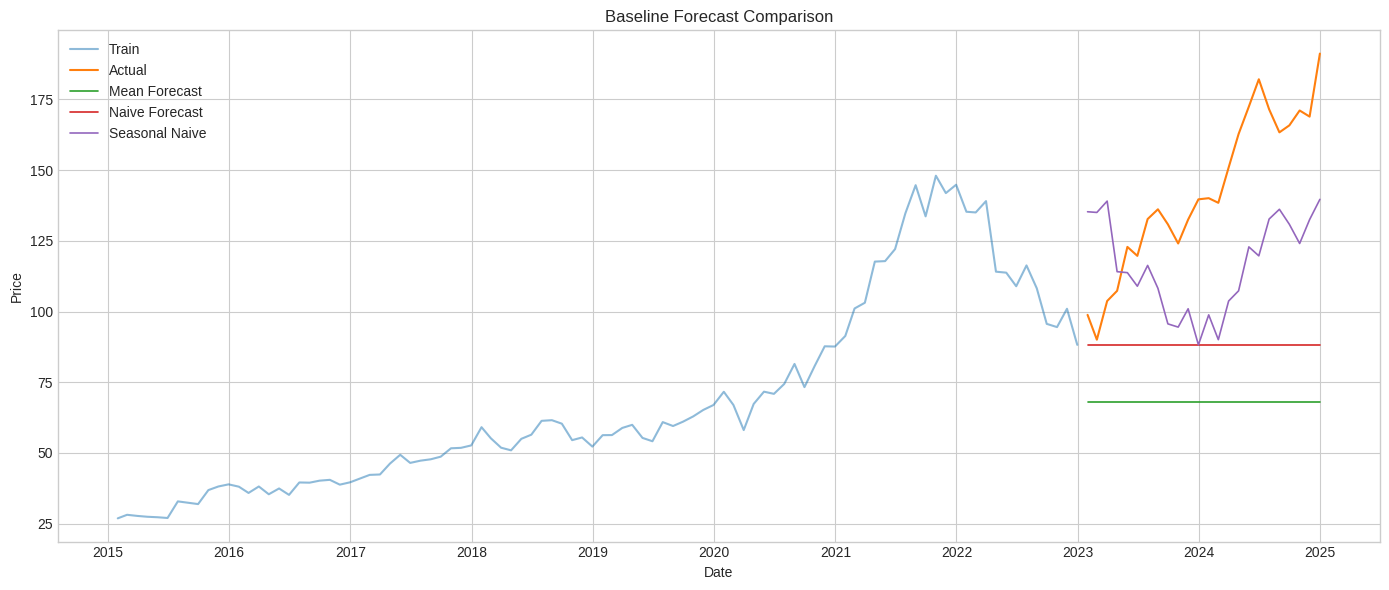

In [14]:
# ============================================
# 14. Baseline 예측 시각화
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Train", alpha=0.5)
plt.plot(test.index, test, label="Actual", linewidth=1.5)
plt.plot(mean_forecast.index, mean_forecast, label="Mean Forecast", linewidth=1.2)
plt.plot(naive_forecast.index, naive_forecast, label="Naive Forecast", linewidth=1.2)
plt.plot(seasonal_naive_forecast.index, seasonal_naive_forecast, label="Seasonal Naive", linewidth=1.2)

plt.title("Baseline Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


## 10. 고정 분할(one-shot) ARIMA 예측
가장 단순한 방식은 학습 구간 전체에 한 번만 모델을 적합하고,  
테스트 구간 전체를 한 번에 예측하는 것입니다.

이 방법은 구현이 쉽지만,  
실제 운영 환경에서 "새로운 데이터가 들어올 때마다 다시 업데이트되는 상황"을 반영하지는 못합니다.


## In-sample 적합과 Out-of-sample 예측을 구분하기
ARIMA 요약표에서 보이는 로그우도, AIC, 잔차 진단은 대부분 **훈련 구간 내부**에서 계산된 정보입니다.  
이 정보는 모형이 과거 데이터를 어느 정도 설명하는지 알려주지만, 그것만으로 미래 예측력이 충분하다고 단정할 수는 없습니다.

따라서 이번 노트북에서는
- 먼저 **train 구간에서 모형을 적합**하고
- 그 다음 **test 구간에서 실제 예측 오차**를 계산하여

두 단계를 분명히 분리합니다.  
이 구분이 바로 예측 실험의 기본 윤리라고 볼 수 있습니다.


In [15]:
# ============================================
# 15. ARIMA 그리드 탐색 (작은 범위)
# ============================================

results = []

for p in [0, 1, 2]:
    for d in [0, 1, 2]:
        for q in [0, 1, 2]:
            try:
                fitted = ARIMA(train, order=(p, d, q)).fit()
                results.append({
                    "p": p, "d": d, "q": q,
                    "AIC": fitted.aic,
                    "BIC": fitted.bic
                })
            except Exception:
                pass

grid_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
display(grid_df.head(10))


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,p,d,q,AIC,BIC
0,2,1,2,589.925399,602.694784
1,0,2,2,592.402362,600.032247
2,1,2,2,593.563031,603.736210
3,1,1,2,593.686255,603.901762
4,2,2,2,594.972765,607.689239
5,2,2,1,594.978207,605.151386
6,1,2,1,597.026382,604.656266
7,2,1,1,599.817888,610.033396
8,0,2,1,602.077968,607.164558
9,0,1,0,602.807078,605.360955


In [16]:
# ============================================
# 16. 고정 분할 ARIMA 적합
# ============================================

best_p = int(grid_df.loc[0, "p"])
best_d = int(grid_df.loc[0, "d"])
best_q = int(grid_df.loc[0, "q"])

print(f"Best ARIMA order by AIC: ({best_p}, {best_d}, {best_q})")

fixed_model = ARIMA(train, order=(best_p, best_d, best_q)).fit()
fixed_forecast = fixed_model.get_forecast(steps=len(test)).predicted_mean

eval_fixed = evaluate_forecast(test, fixed_forecast, f"Fixed ARIMA({best_p},{best_d},{best_q})")
display(eval_fixed)


Best ARIMA order by AIC: (2, 1, 2)


,Model,MAE,RMSE,MAPE
0,"Fixed ARIMA(2,1,2)",62.3699,68.962748,41.140318


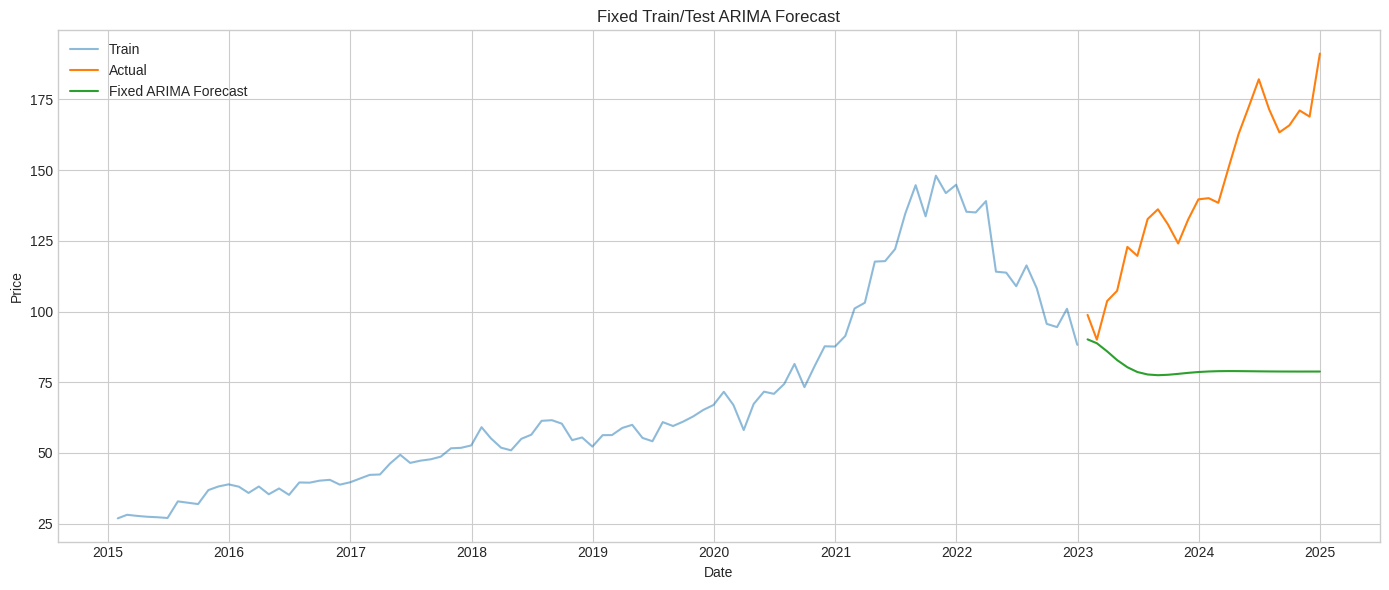

In [17]:
# ============================================
# 17. 고정 분할 ARIMA 예측 시각화
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Train", alpha=0.5)
plt.plot(test.index, test, label="Actual", linewidth=1.5)
plt.plot(fixed_forecast.index, fixed_forecast, label="Fixed ARIMA Forecast", linewidth=1.5)

plt.title("Fixed Train/Test ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Walk-forward validation의 핵심 아이디어
이제 이번 장의 핵심인 **walk-forward validation**으로 넘어갑니다.

기본 아이디어는 다음과 같습니다.

- 한 시점까지의 데이터만으로 모델을 학습
- 다음 시점 1-step ahead를 예측
- 실제값을 확인
- 데이터 창(window)을 앞으로 이동
- 다시 학습하고 예측 반복

즉, **매 시점마다 “그 당시 알 수 있었던 정보만” 사용하여 예측**하는 방식입니다.


## Walk-forward validation을 왜 따로 하는가?
고정 분할(one-shot forecast)은 한 번 학습한 모델로 테스트 구간 전체를 예측합니다.  
이 방법은 구현이 간단하지만, 실제 현업에서는 보통 **새로운 데이터가 도착할 때마다 모델을 다시 업데이트하거나 재적합**합니다.

Walk-forward validation은 바로 이 현실을 모사합니다.

- 특정 시점까지의 정보만 사용해 1-step ahead 예측
- 실제값을 확인
- 학습 구간을 갱신
- 다시 다음 시점 예측

즉, walk-forward validation은 단순한 점수 계산이 아니라 **현실적인 운영 프로세스를 실험실 안에서 재현하는 절차**입니다.


## 12. Expanding Window Walk-forward
Expanding window는 시간이 지날수록 훈련 데이터가 계속 늘어나는 방식입니다.

예:
- 1회차: 처음 80개 관측치로 학습 → 다음 1개 예측
- 2회차: 처음 81개 관측치로 학습 → 다음 1개 예측
- 3회차: 처음 82개 관측치로 학습 → 다음 1개 예측

즉, 과거의 모든 데이터를 계속 누적하여 사용합니다.


## Expanding window의 해석
Expanding window는 시간이 흐를수록 **모든 과거 정보를 계속 안고 가는 방식**입니다.  
따라서 데이터 생성 구조가 비교적 안정적이고, 오래된 정보도 여전히 유용하다고 판단될 때 적합합니다.

예를 들어,
- 장기 추세를 함께 학습해야 하는 거시경제 데이터
- 충분히 긴 이력 전체를 활용하는 편이 유리한 수요 데이터

에서는 expanding window가 자연스러운 선택이 될 수 있습니다.


In [18]:
# ============================================
# 18. Expanding window walk-forward 함수
# ============================================

def walk_forward_expanding(series, train_size, order=(1,1,1)):
    predictions = []
    actuals = []
    forecast_index = []

    for i in range(len(series) - train_size):
        train_slice = series.iloc[:train_size + i]
        actual_value = series.iloc[train_size + i]

        model = ARIMA(train_slice, order=order).fit()
        pred = model.forecast(steps=1).iloc[0]

        predictions.append(pred)
        actuals.append(actual_value)
        forecast_index.append(series.index[train_size + i])

    pred_series = pd.Series(predictions, index=forecast_index, name="Expanding_Forecast")
    actual_series = pd.Series(actuals, index=forecast_index, name="Actual")
    return actual_series, pred_series


In [19]:
# ============================================
# 19. Expanding window 실행
# ============================================

train_size = len(train)

actual_exp, pred_exp = walk_forward_expanding(
    series=series,
    train_size=train_size,
    order=(best_p, best_d, best_q)
)

eval_exp = evaluate_forecast(actual_exp, pred_exp, f"Expanding ARIMA({best_p},{best_d},{best_q})")
display(eval_exp)


,Model,MAE,RMSE,MAPE
0,"Expanding ARIMA(2,1,2)",9.296907,10.808592,6.696145


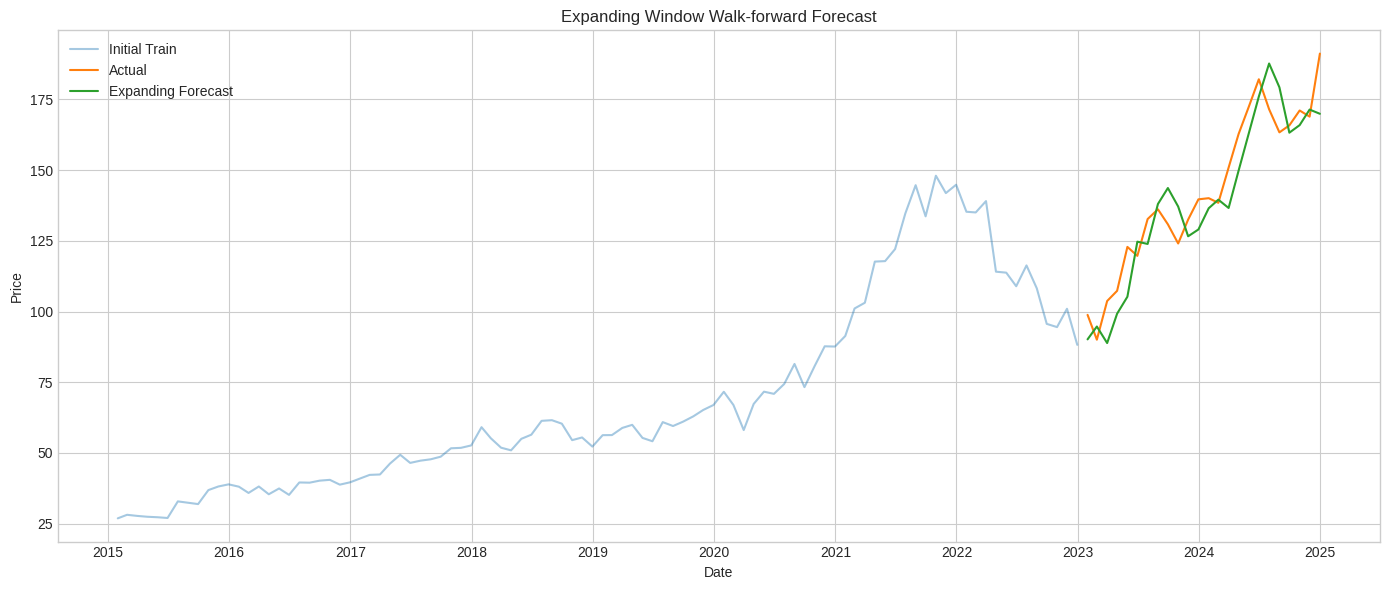

In [20]:
# ============================================
# 20. Expanding window 결과 시각화
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Initial Train", alpha=0.4)
plt.plot(actual_exp.index, actual_exp, label="Actual", linewidth=1.5)
plt.plot(pred_exp.index, pred_exp, label="Expanding Forecast", linewidth=1.5)

plt.title("Expanding Window Walk-forward Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Rolling Window Walk-forward
Rolling window는 최근 일정 길이의 데이터만 사용하여 계속 이동하는 방식입니다.

예:
- 1회차: 최근 60개 관측치로 학습 → 다음 1개 예측
- 2회차: 한 칸 앞으로 이동한 최근 60개 관측치로 학습 → 다음 1개 예측

즉, 오래된 데이터는 버리고 최근 정보만 반영합니다.  
구조 변화가 빠른 데이터에서는 이 방식이 더 유리할 수 있습니다.


## Rolling window의 해석
Rolling window는 최근 일정 구간만 유지하고 오래된 데이터를 버립니다.  
즉, **최근 정보에 더 높은 가중치를 주는 방식**이라고 볼 수 있습니다.

이 방식은 특히 다음 상황에서 유용합니다.

- 구조 변화가 빠른 시장 데이터
- 오래된 패턴이 더 이상 유효하지 않을 가능성이 큰 데이터
- 최근 국면에 맞는 예측이 더 중요한 운영 환경

따라서 rolling window는 단순한 기술적 선택이 아니라, **데이터의 안정성과 환경 변화 속도에 대한 가정**을 반영하는 설계입니다.


In [21]:
# ============================================
# 21. Rolling window walk-forward 함수
# ============================================

def walk_forward_rolling(series, train_size, window_size, order=(1,1,1)):
    predictions = []
    actuals = []
    forecast_index = []

    for i in range(len(series) - train_size):
        end_idx = train_size + i
        start_idx = max(0, end_idx - window_size)

        train_slice = series.iloc[start_idx:end_idx]
        actual_value = series.iloc[end_idx]

        model = ARIMA(train_slice, order=order).fit()
        pred = model.forecast(steps=1).iloc[0]

        predictions.append(pred)
        actuals.append(actual_value)
        forecast_index.append(series.index[end_idx])

    pred_series = pd.Series(predictions, index=forecast_index, name="Rolling_Forecast")
    actual_series = pd.Series(actuals, index=forecast_index, name="Actual")
    return actual_series, pred_series


In [22]:
# ============================================
# 22. Rolling window 실행
# ============================================

window_size = 60  # 최근 60개월만 사용

actual_roll, pred_roll = walk_forward_rolling(
    series=series,
    train_size=train_size,
    window_size=window_size,
    order=(best_p, best_d, best_q)
)

eval_roll = evaluate_forecast(actual_roll, pred_roll, f"Rolling ARIMA({best_p},{best_d},{best_q})")
display(eval_roll)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Model,MAE,RMSE,MAPE
0,"Rolling ARIMA(2,1,2)",8.48766,9.976489,6.172415


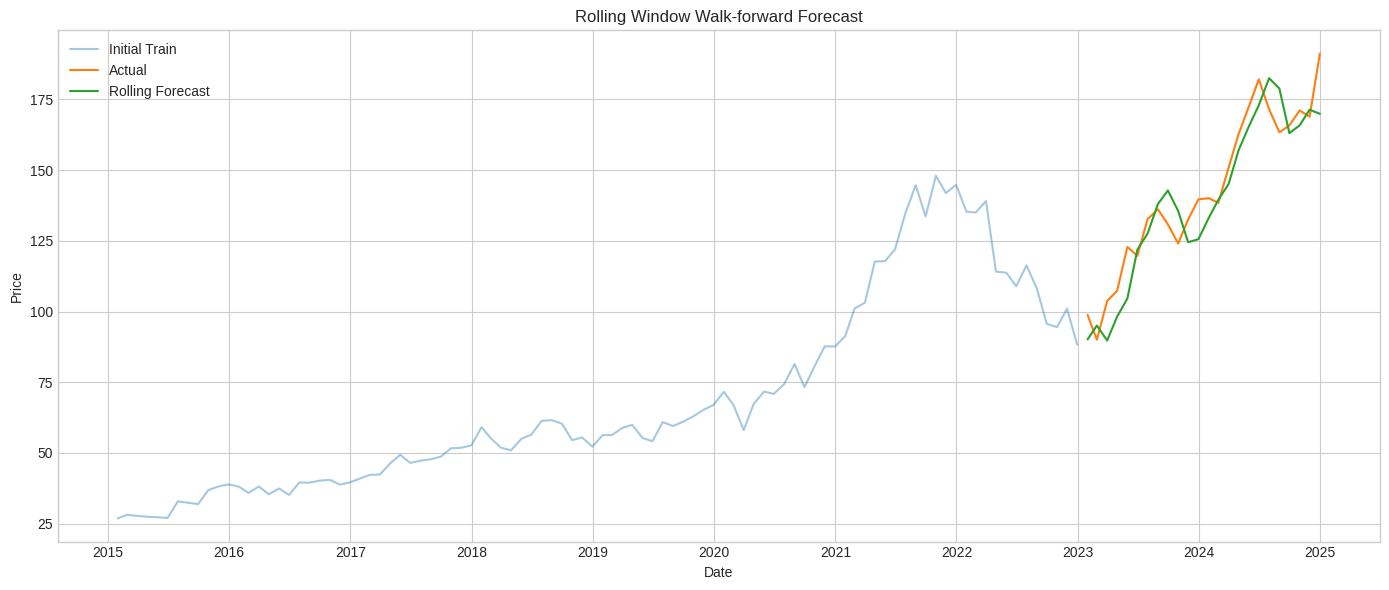

In [23]:
# ============================================
# 23. Rolling window 결과 시각화
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Initial Train", alpha=0.4)
plt.plot(actual_roll.index, actual_roll, label="Actual", linewidth=1.5)
plt.plot(pred_roll.index, pred_roll, label="Rolling Forecast", linewidth=1.5)

plt.title("Rolling Window Walk-forward Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


## 14. 모든 모델 성능 비교
이제 베이스라인, 고정 분할 ARIMA, expanding walk-forward, rolling walk-forward를 한 표에서 비교합니다.


In [24]:
# ============================================
# 24. 성능 비교표
# ============================================

all_eval = pd.concat(
    [baseline_eval, eval_fixed, eval_exp, eval_roll],
    ignore_index=True
).sort_values("MAPE")

display(all_eval)


,Model,MAE,RMSE,MAPE
5,"Rolling ARIMA(2,1,2)",8.487660,9.976489,6.172415
4,"Expanding ARIMA(2,1,2)",9.296907,10.808592,6.696145
2,Seasonal Naive,36.497605,39.280590,25.710066
1,Naive,54.169163,60.599838,35.539837
3,"Fixed ARIMA(2,1,2)",62.369900,68.962748,41.140318
0,Mean,74.314016,79.124048,50.257512


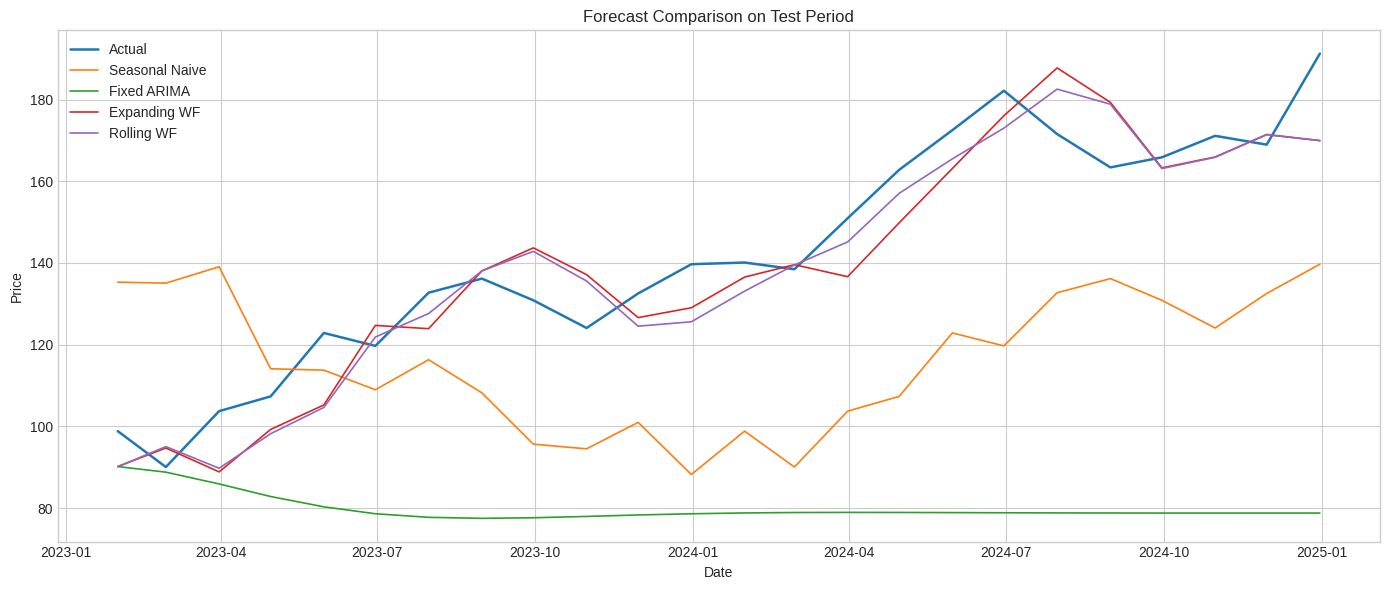

In [25]:
# ============================================
# 25. 주요 예측 결과를 한 번에 시각화
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(test.index, test, label="Actual", linewidth=1.8)
plt.plot(seasonal_naive_forecast.index, seasonal_naive_forecast, label="Seasonal Naive", linewidth=1.2)
plt.plot(fixed_forecast.index, fixed_forecast, label="Fixed ARIMA", linewidth=1.2)
plt.plot(pred_exp.index, pred_exp, label="Expanding WF", linewidth=1.2)
plt.plot(pred_roll.index, pred_roll, label="Rolling WF", linewidth=1.2)

plt.title("Forecast Comparison on Test Period")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


## 14-1. 평가 지표를 해석할 때의 주의점
같은 예측이라도 어떤 지표를 쓰느냐에 따라 해석이 달라질 수 있습니다.

- **MAE**: 평균적인 절대 오차 규모를 직관적으로 보여줍니다.
- **RMSE**: 큰 오차에 더 큰 페널티를 주므로, “가끔 크게 틀리는 모델”에 더 민감합니다.
- **MAPE**: 퍼센트 기준이라 비교가 편리하지만, 실제값이 0에 가까우면 왜곡될 수 있습니다.

즉, 성능 평가는 단일 숫자 하나로 끝내기보다 **여러 지표를 함께 보고, 데이터의 스케일과 비즈니스 의미를 같이 해석**해야 합니다.


## 15. 결과 해석의 핵심 포인트
이제 다음 질문에 답할 수 있어야 합니다.

1. 고정 분할 예측보다 walk-forward validation이 왜 더 현실적인가?
2. expanding window와 rolling window는 어떤 상황에서 각각 유리한가?
3. 복잡한 ARIMA가 Seasonal Naive보다 정말 나은가?
4. 성능표에서 가장 좋은 모델이 항상 실무적으로도 최선인가?

특히 시계열에서는 **예측 성능 + 계산 비용 + 운영 편의성**을 함께 고려해야 합니다.


## 자주 발생하는 실수 (Common Mistakes)
이번 장에서 특히 자주 나오는 실수는 다음과 같습니다.

1. **훈련 구간 성능을 예측 성능처럼 해석하는 실수**  
   잔차가 작고 AIC가 낮다고 해서 반드시 미래 예측력이 좋은 것은 아닙니다.

2. **무작위 분할을 사용하는 실수**  
   시계열에서 셔플은 곧 데이터 누수입니다.

3. **베이스라인 비교를 생략하는 실수**  
   복잡한 모델이 Seasonal Naive보다 나쁘면 실무적 설득력이 떨어집니다.

4. **walk-forward 없이 한 번의 split만으로 결론을 내리는 실수**  
   데이터가 작거나 국면 변화가 있을 때, 결과가 특정 구간에 과도하게 의존할 수 있습니다.

이 실수들을 피하는 것이 곧 재현 가능한 예측 실험의 출발점입니다.


## 16. 실습 정리
이번 실습에서 확인한 핵심은 다음과 같습니다.

- 시계열 예측은 in-sample 적합보다 out-of-sample 성능이 중요하다.
- 데이터는 반드시 시간 순서대로 분할해야 한다.
- Mean, Naive, Seasonal Naive 같은 baseline은 필수 비교 대상이다.
- 고정 분할 예측은 간단하지만 현실적 업데이트 상황을 충분히 반영하지 못할 수 있다.
- walk-forward validation은 시간의 흐름을 유지한 채 모델을 반복 평가하는 실전형 방법이다.
- expanding window는 모든 과거 정보를 누적하고, rolling window는 최근 구간만 반영한다.
- 성능 평가는 MAE, RMSE, MAPE를 함께 보고, baseline 대비 개선 여부로 해석해야 한다.


## 17. 연습문제 (Exercises)

1. GOOGL 대신 AAPL 또는 MSFT 월별 종가를 사용하여 같은 walk-forward validation을 수행하시오.

2. rolling window의 길이를 36, 48, 60으로 바꾸어 성능이 어떻게 달라지는지 비교하시오.

3. Seasonal Naive가 ARIMA보다 더 좋은 결과를 보일 경우, 왜 그런 현상이 나타날 수 있는지 설명하시오.

4. expanding window와 rolling window의 차이를 구조 변화(structural change) 관점에서 설명하시오.

5. MAPE가 낮더라도 실제 비즈니스 의사결정에서 그 모델을 바로 채택하기 어려운 이유를 논의하시오.
